In [1]:
# -*- coding: utf-8 -*-
"""Lab-6-SVM.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1Az59g2DkfeHUafr25_b2GR321r7kn0kN
"""

import pandas as pd
from sklearn.datasets import load_digits
digits = load_digits()

digits.target

dir(digits)

digits.target_names

df = pd.DataFrame(digits.data,digits.target)
df.head()

df['target'] = digits.target
df.head(20)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('target',axis='columns'), df.target, test_size=0.3)

"""Using RBF kernel"""

from sklearn.svm import SVC
rbf_model = SVC(kernel='rbf')

len(X_train)

len(X_test)

rbf_model.fit(X_train, y_train)

rbf_model.score(X_test,y_test)

"""Using Linear kernel"""

linear_model = SVC(kernel='linear')
linear_model.fit(X_train,y_train)

linear_model.score(X_test,y_test)

0.9814814814814815

In [5]:
from google.colab import files
uploaded = files.upload()

Saving letter-recognition.xlsx to letter-recognition.xlsx
Saving iris (1).xlsx to iris (1).xlsx


===== IRIS DATASET =====

Linear Kernel Accuracy: 1.0

Confusion Matrix (Linear):
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


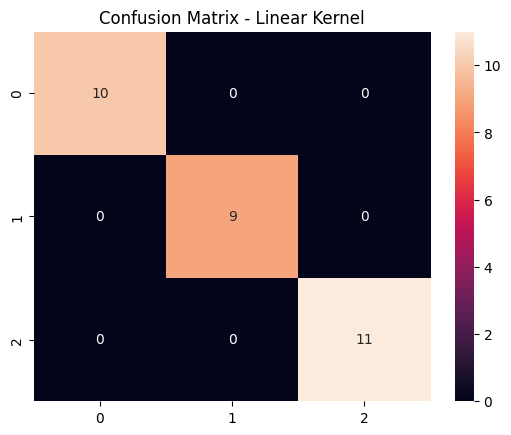


RBF Kernel Accuracy: 1.0

Confusion Matrix (RBF):
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


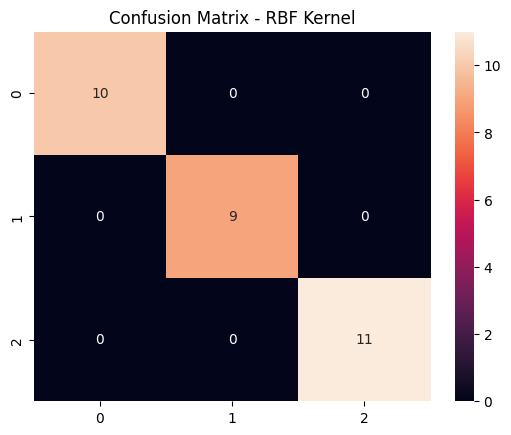


===== LETTER RECOGNITION DATASET =====

Accuracy: 0.8545

Confusion Matrix:
 [[140   1   0   0   0   0   2   0   0   2   0   0   0   0   0   0   0   1
    1   0   0   1   0   0   1   0]
 [  1 133   0   3   0   0   0   5   0   0   1   0   0   1   0   1   0   6
    1   0   0   1   0   0   0   0]
 [  0   0 117   0   1   0   4   2   0   0   6   1   0   0   3   0   0   0
    1   0   2   0   0   0   0   0]
 [  0   6   0 141   0   0   0   2   0   1   2   0   0   1   1   0   0   0
    0   2   0   0   0   0   0   0]
 [  0   1   2   0 127   0   4   0   0   0   1   1   0   0   0   0   1   1
    2   1   0   0   0   0   0   0]
 [  0   0   0   0   3 127   0   1   2   1   0   0   0   0   0   1   0   0
    2   3   0   0   0   0   0   0]
 [  0   1   8   2   0   0 129   2   0   1   3   0   0   0   0   0   7   1
    2   0   0   2   2   0   0   0]
 [  1   4   1  10   1   2   0  85   0   3   6   0   0   2  10   1   2  12
    0   0   2   0   0   1   1   0]
 [  0   0   0   3   0   2   0   0 127   6   0   2 

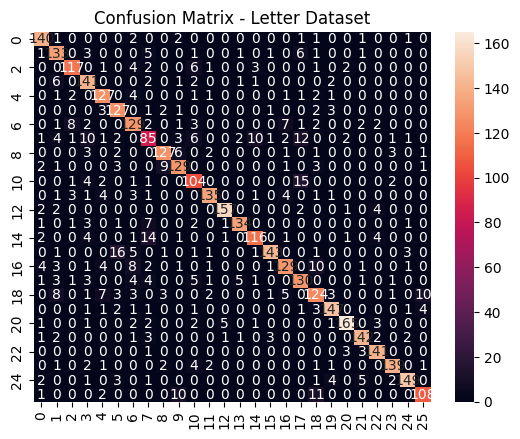


AUC Score: 0.9949952550000001


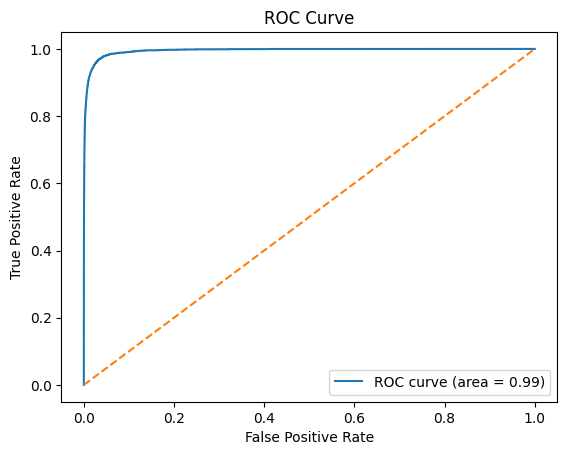

In [13]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# ==================================
# 1. SVM CLASSIFIER - IRIS DATASET
# ==================================

print("===== IRIS DATASET =====")

# Load iris dataset
iris = pd.read_excel("iris (1).xlsx")

# Features and target
X = iris.iloc[:, :-1]
y = iris.iloc[:, -1]

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------- Linear Kernel --------
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)

print("\nLinear Kernel Accuracy:", accuracy_score(y_test, y_pred_linear))

cm_linear = confusion_matrix(y_test, y_pred_linear)
print("\nConfusion Matrix (Linear):\n", cm_linear)

sns.heatmap(cm_linear, annot=True, fmt='d')
plt.title("Confusion Matrix - Linear Kernel")
plt.show()


# -------- RBF Kernel --------
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)

print("\nRBF Kernel Accuracy:", accuracy_score(y_test, y_pred_rbf))

cm_rbf = confusion_matrix(y_test, y_pred_rbf)
print("\nConfusion Matrix (RBF):\n", cm_rbf)

sns.heatmap(cm_rbf, annot=True, fmt='d')
plt.title("Confusion Matrix - RBF Kernel")
plt.show()


# ==================================
# 2. LETTER RECOGNITION DATASET
# ==================================

print("\n===== LETTER RECOGNITION DATASET =====")

# Load dataset
letter = pd.read_excel("letter-recognition.xlsx")

# First column = target (letter)
X = letter.iloc[:, 1:]
y = letter.iloc[:, 0]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train SVM model
model = SVC(kernel='linear', probability=True)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Letter Dataset")
plt.show()

# ROC and AUC
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

y_score = model.predict_proba(X_test)

fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc = auc(fpr, tpr)

print("\nAUC Score:", roc_auc)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()